<a href="https://colab.research.google.com/github/AbhinavKumar0000/Machine_learning/blob/main/SVM_Kernel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

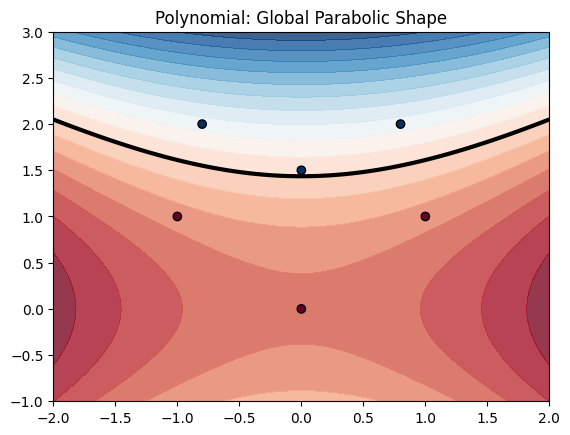

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# DATASET: A "U" shape that a straight line can't cut
X = np.array([[-1, 1], [0, 0], [1, 1], [-0.8, 2], [0, 1.5], [0.8, 2]])
y = np.array([0, 0, 0, 1, 1, 1]) # 0 is bottom, 1 is top

# FUNCTION: Polynomial Degree 2
poly_svc = svm.SVC(kernel='poly', degree=2, C=1).fit(X, y)

# PLOT: Visualization of the "Bending"
xx, yy = np.meshgrid(np.linspace(-2, 2, 500), np.linspace(-1, 3, 500))
Z = poly_svc.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.8) # The "Depth" of the function
plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=3) # The "Boundary" (Sea Level)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='RdBu')
plt.title("Polynomial: Global Parabolic Shape")
plt.show()

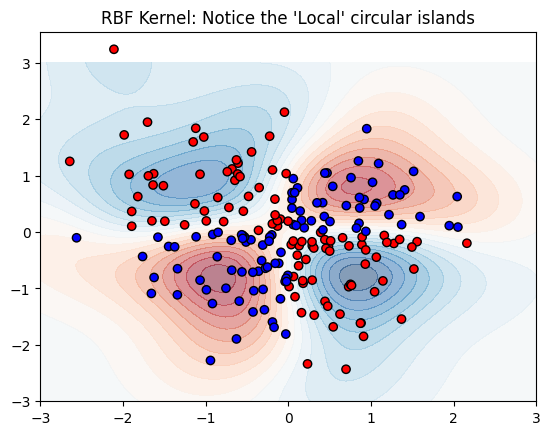

In [ ]:
# Create data with an "Island" of one class inside another
X_rbf = np.random.randn(200, 2)
y_rbf = np.logical_xor(X_rbf[:, 0] > 0, X_rbf[:, 1] > 0) # XOR Pattern

model_rbf = svm.SVC(kernel='rbf', gamma=1)
model_rbf.fit(X_rbf, y_rbf)

# Plotting the "Bubbles"
xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
Z = model_rbf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.5)
plt.scatter(X_rbf[:,0], X_rbf[:,1], c=y_rbf, cmap='bwr', edgecolors='k')
plt.title("RBF Kernel: Notice the 'Local' circular islands")
plt.show()

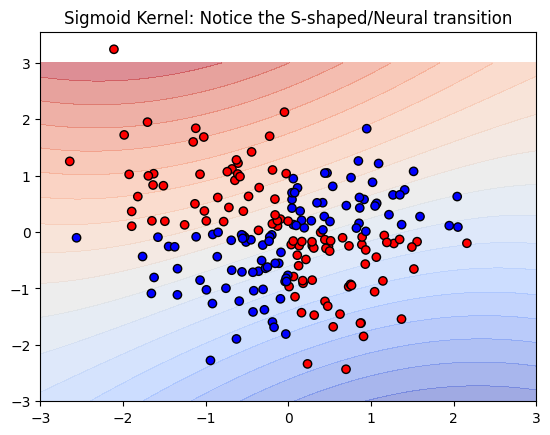

In [ ]:
# Use the same XOR data to see the difference
model_sig = svm.SVC(kernel='sigmoid', gamma=0.1, coef0=0)
model_sig.fit(X_rbf, y_rbf)

Z_sig = model_sig.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z_sig, levels=20, cmap='coolwarm', alpha=0.5)
plt.scatter(X_rbf[:,0], X_rbf[:,1], c=y_rbf, cmap='bwr', edgecolors='k')
plt.title("Sigmoid Kernel: Notice the S-shaped/Neural transition")
plt.show()